# Urban Safety — Classification
Tests whether built-environment features (lighting, visibility, connectivity, enclosure) predict street-level crime rate.

**Hypothesis:**  

**Method (Option A):** Features come from OSM. Target (y) comes from real police crime data.  
The regression learns its own coefficients — we then compare them against the hypothesized weights.

## Cell 1 — Imports and config

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import osmnx as ox
import rasterio
from shapely.geometry import box
from shapely.geometry import Point

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set(rc={'figure.figsize': (8, 8)})
pd.set_option('display.float_format', '{:.3f}'.format)
ox.settings.requests_timeout = 2000

# ── File paths ────────────────────────────────────────────────────────────
CRIME_CSV       = 'csvFiles/london_crime_2025.csv'
MAPILLARY_CSV   = 'csvFiles/mapillary_streetlights_london_ids.csv'
FEATURES_CACHE  = 'csvFiles/features_all_boroughs.csv'
VIIRS_TIF       = 'tif/VNL_UK_2025.tif'

# ── Set to True only on first run or when adding boroughs ─────────────────
RECOMPUTE = False

# ── Borough list — 6 representative boroughs for balanced coverage ─────────
# Added Hackney (north) and Lambeth (south) for better geographic diversity.
# Covers central, north, east, and south London. Extracts in ~35-45 minutes.
OSM_PLACES = [
    'City of Westminster, London, UK',           # Central, very dense
    'London Borough of Islington, London, UK',   # North, dense
    'London Borough of Hackney, London, UK',     # North-east, dense residential
    'London Borough of Tower Hamlets, London, UK',  # East, dense
    'London Borough of Southwark, London, UK',   # South, mixed density
]

# ── Spatial config ────────────────────────────────────────────────────────
CRS_METRIC   = 'EPSG:27700'
GRID_M       = 200
BUFFER_M     = 50
FEATURE_COLS = ['lighting', 'visibility', 'connectivity', 'enclosure']

# ── Severity ──────────────────────────────────────────────────────────────
SEVERITY_ORDER   = ['Low', 'Medium', 'High']
SEVERITY_COLORS  = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
SEVERITY_WEIGHTS = {'Low': 1, 'Medium': 2, 'High': 3}

## Cell 2 — Pre-loop setup
Load the full London crime dataset and Mapillary lamp locations once.
Both are clipped to each borough's boundary inside the loop.

In [2]:
def calculate_logarithmic_crime_score(petty_count, medium_count, serious_count):
    """
    score = [1.3^ln(petty+1) - 1] + [2.0^ln(medium+1) - 1] + [3.0^ln(serious+1) - 1]
    0 crimes → score = 0. Serious crimes grow faster than petty crimes.
    """
    petty_score   = np.maximum(0, np.power(1.3, np.log(petty_count   + 1)) - 1)
    medium_score  = np.maximum(0, np.power(2.0, np.log(medium_count  + 1)) - 1)
    serious_score = np.maximum(0, np.power(3.0, np.log(serious_count + 1)) - 1)
    return petty_score + medium_score + serious_score

# ── Load crime data once (London-wide) ────────────────────────────────────
print('Loading crime data...')
crimes = pd.read_csv(CRIME_CSV)
crimes = crimes.dropna(subset=['severity_class'])
crimes_gdf = gpd.GeoDataFrame(
    crimes,
    geometry=gpd.points_from_xy(crimes['longitude'], crimes['latitude']),
    crs='EPSG:4326'
).to_crs(CRS_METRIC)
crimes_gdf['category'] = crimes_gdf['severity_class'].map({
    'Low': 'Petty', 'Medium': 'Medium', 'High': 'Serious'
})
print(f'  Classified crimes: {len(crimes_gdf):,}')

# ── Load Mapillary lamps once (London-wide) ───────────────────────────────
print('Loading Mapillary street lamps...')
lamps_df  = pd.read_csv(MAPILLARY_CSV)
lamps_geo = gpd.GeoDataFrame(
    lamps_df,
    geometry=gpd.points_from_xy(lamps_df['longitude'], lamps_df['latitude']),
    crs='EPSG:4326'
).to_crs(CRS_METRIC)
print(f'  Street lamps: {len(lamps_geo):,}')

Loading crime data...
  Classified crimes: 984,760
Loading Mapillary street lamps...
  Street lamps: 61,784


## Cell 3 — Borough feature extraction loop
Iterates over `OSM_PLACES`. For each borough: fetches OSM street network and buildings,
clips crimes and lamps to boundary, computes the 4 features per segment (vectorised),
scores and labels each segment, then tags rows with the borough name.

Set `RECOMPUTE = True` in Cell 1 to run the loop. Otherwise loads from `FEATURES_CACHE`.

**Features computed per segment (50 m buffer around each street segment):**
- `osmid` — OpenStreetMap unique street segment identifier
- `lighting` — Mapillary lamp density (lamps per 100 m of street)
- `visibility` — mean building height of buildings whose centroid falls in buffer (meters)
- `connectivity` — sum of node degrees at both segment endpoints

- `enclosure` — building footprint coverage ratio × street canyon ratio (H/W normalized)- `crime_count` — total number of crimes in segment (integer)
- `crime_score` — exponential weighted crime score (0–∞)

In [3]:
if RECOMPUTE:
    all_features = []

    for place in OSM_PLACES:
        print(f'\n── {place} ──')

        # ── OSM: street network ───────────────────────────────────────────
        G     = ox.graph_from_place(place, network_type='drive')
        edges = ox.graph_to_gdfs(G, nodes=False).to_crs(CRS_METRIC)
        study_area = ox.geocode_to_gdf(place).to_crs(CRS_METRIC)
        boundary   = study_area.geometry.iloc[0]
        print(f'  Segments : {len(edges):,}')

        # ── OSM: buildings with height fallback ───────────────────────────
        bldg_raw  = ox.features_from_place(place, tags={'building': True})
        buildings = bldg_raw[bldg_raw.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()
        buildings = buildings.to_crs(CRS_METRIC)
        buildings['height_m'] = pd.to_numeric(buildings.get('height'), errors='coerce')
        has_levels = (
            buildings['height_m'].isna() &
            buildings.get('building:levels', pd.Series(dtype=str)).notna()
        )
        buildings.loc[has_levels, 'height_m'] = (
            pd.to_numeric(buildings.loc[has_levels, 'building:levels'], errors='coerce') * 3.0
        )
        h_median = buildings['height_m'].median()
        buildings['height_m'] = buildings['height_m'].fillna(h_median if pd.notna(h_median) else 9.0)
        print(f'  Buildings: {len(buildings):,}  (median height {buildings["height_m"].median():.1f} m)')

        # ── Clip crimes and lamps to borough boundary ─────────────────────
        borough_crimes = crimes_gdf[crimes_gdf.geometry.within(boundary)].copy()
        borough_lamps  = lamps_geo[lamps_geo.geometry.within(boundary)].copy()
        print(f'  Crimes   : {len(borough_crimes):,}  |  Lamps: {len(borough_lamps):,}')

        # ── Buffer all segments at once (50 m, flat end caps) ─────────────
        edges_r  = edges.reset_index()          # u, v, key → columns; index = 0..n
        segs_buf = edges_r.copy()
        segs_buf['geometry'] = edges_r.geometry.buffer(BUFFER_M, cap_style=2)

        # ── Connectivity ──────────────────────────────────────────────────
        node_deg     = dict(G.degree())
        connectivity = (
            edges_r['u'].map(node_deg).fillna(0) +
            edges_r['v'].map(node_deg).fillna(0)
        ).values

        # ── Street width: extract from OSM, use borough median as fallback ──
        street_width = pd.to_numeric(edges.get('width'), errors='coerce')
        width_median = street_width.median()
        if pd.isna(width_median) or street_width.notna().sum() / len(street_width) < 0.2:
            width_median = 10.0  # London residential street typical width (meters)
        street_width = street_width.fillna(width_median)
        print(f'  Street width: {street_width.notna().sum():,} tagged, median {width_median:.1f} m')

        # ── Visibility: mean building height per buffer ───────────────────
        bldg_c = buildings[['geometry', 'height_m']].copy()
        bldg_c['geometry'] = buildings.geometry.centroid
        vis_join   = gpd.sjoin(bldg_c, segs_buf[['geometry']], how='inner', predicate='within')
        visibility = (
            vis_join.groupby('index_right')['height_m']
            .mean()
            .reindex(segs_buf.index, fill_value=0.0)
            .values
        )

        # ── Enclosure: building footprint × street canyon ratio (H/W) ──────
        enc_join  = gpd.sjoin(buildings[['geometry', 'height_m']], segs_buf[['geometry']], 
                              how='inner', predicate='intersects')
        buf_areas = segs_buf.geometry.area.values
        enclosure = np.zeros(len(segs_buf))
        for seg_i, grp in enc_join.groupby('index_right'):
            buf_geom       = segs_buf.loc[seg_i, 'geometry']
            clipped_area   = buildings.loc[grp.index, 'geometry'].intersection(buf_geom).area.sum()
            footprint_ratio = clipped_area / buf_areas[seg_i]
            
            # Mean height of buildings in this segment
            h_mean = buildings.loc[grp.index, 'height_m'].mean()
            
            # Street canyon ratio (height / width), normalized
            w_street = street_width.iloc[seg_i] if seg_i < len(street_width) else width_median
            canyon_ratio = h_mean / max(w_street, 1.0)
            canyon_normalized = min(canyon_ratio / 2.0, 1.0)  # cap at ~0.5
            
            # Combined: denser + narrower = higher enclosure
            enclosure[seg_i] = footprint_ratio * canyon_normalized

        # ── Lighting: Mapillary lamp density (lamps per 100 m) ────────────
        if len(borough_lamps) > 0:
            lamp_join   = gpd.sjoin(borough_lamps[['geometry']], segs_buf[['geometry']], how='inner', predicate='within')
            lamp_counts = lamp_join.groupby('index_right').size().reindex(segs_buf.index, fill_value=0).values
        else:
            lamp_counts = np.zeros(len(segs_buf))
        seg_lengths = edges_r.geometry.length.values
        lighting    = np.where(seg_lengths > 0, lamp_counts / seg_lengths * 100, 0.0)

        # ── Assemble features GeoDataFrame ────────────────────────────────
        borough_features = gpd.GeoDataFrame({
            'geometry'      : segs_buf['geometry'].values,
            'osmid'         : edges_r['osmid'].values,
            'lighting'      : lighting,
            'visibility'    : visibility,
            'connectivity'  : connectivity,
            'enclosure'     : enclosure,
            'borough'       : place,
        }, crs=CRS_METRIC)

        # ── Crime scoring and crime count ─────────────────────────────────
        borough_features['crime_score'] = 0.0
        borough_features['crime_count'] = 0.0
        if len(borough_crimes) > 0:
            crime_join = gpd.sjoin(
                borough_crimes[['geometry', 'category']],
                borough_features[['geometry']],
                how='inner', predicate='within'
            )
            seg_counts = crime_join.groupby(['index_right', 'category']).size().unstack(fill_value=0)
            for cat in ['Petty', 'Medium', 'Serious']:
                if cat not in seg_counts.columns:
                    seg_counts[cat] = 0
            scores = seg_counts.apply(
                lambda r: calculate_logarithmic_crime_score(r['Petty'], r['Medium'], r['Serious']), axis=1
            )
            borough_features.loc[scores.index, 'crime_score'] = scores
            
            # Total crime count per segment
            total_crime_counts = crime_join.groupby('index_right').size()
            borough_features.loc[total_crime_counts.index, 'crime_count'] = total_crime_counts.values

        print(f'  Done — {len(borough_features):,} segments scored')
        all_features.append(borough_features)

    # ── Combine all boroughs and cache ────────────────────────────────────
    features = pd.concat(all_features, ignore_index=True)
    print(f'\n✓ Combined: {len(features):,} segments across {len(OSM_PLACES)} boroughs')
    features.to_csv(FEATURES_CACHE, index=False)
    print(f'✓ Saved to {FEATURES_CACHE}')

else:
    if not os.path.exists(FEATURES_CACHE):
        raise FileNotFoundError(
            f'{FEATURES_CACHE} not found. Set RECOMPUTE = True in Cell 1 to generate it.'
        )
    features = pd.read_csv(FEATURES_CACHE)
    print(f'✓ Loaded {len(features):,} segments from {FEATURES_CACHE}')
    print(f'  Boroughs : {features["borough"].nunique()}')
    print(features['borough'].value_counts().to_string())

✓ Loaded 35,980 segments from csvFiles/features_all_boroughs.csv
  Boroughs : 5
borough
London Borough of Southwark, London, UK        9757
London Borough of Tower Hamlets, London, UK    7618
City of Westminster, London, UK                7558
London Borough of Hackney, London, UK          5863
London Borough of Islington, London, UK        5184


## Cell 3a — OSM street lamp coverage (archival)
Original diagnostic showing sparse OSM lamp tagging. Superseded by Mapillary data.
Requires `RECOMPUTE = True` to have run and a manual OSM lamp fetch to populate `lamps`.

In [ ]:
# NOTE: This cell is archival. `lamps` (OSM-tagged lamps) and `edges` are only
# available after running Cell 3 with RECOMPUTE = True. `place` holds the last
# borough processed. Run manually if needed for OSM vs Mapillary comparison.

# lamps_osm = ox.features_from_place(place, tags={'highway': 'street_lamp'})
# lamps_osm = lamps_osm[lamps_osm.geometry.geom_type == 'Point'].to_crs(CRS_METRIC)

# fig, ax = plt.subplots(figsize=(10, 10))
# edges.plot(ax=ax, linewidth=0.5, color='#cccccc', zorder=1)
# lamps_osm.plot(ax=ax, markersize=8, color='gold', edgecolor='darkorange',
#                linewidth=0.5, zorder=3, label=f'OSM street lamps ({len(lamps_osm):,})')
# ax.set_title(f'OSM street lamps — {place}', fontsize=13)
# ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
# ax.set_aspect('equal'); ax.legend(fontsize=10)
# plt.tight_layout(); plt.show()
print('Cell 3a is archival — uncomment above to run.')

## Cell 3b — VIIRS nighttime lights (archived — broken)
Replaced by Mapillary street lamp data. VIIRS resolution (~500 m/pixel) was too coarse
for 50 m segment buffers. Cell is kept for reference but will not run (`rio_mask` import missing).

In [ ]:
# ARCHIVED — do not run. rio_mask was never imported; cell is kept for reference only.
# from rasterio.mask import mask as rio_mask  ← missing import
# See Cell 3b markdown for explanation of why VIIRS was dropped.

## Cell 3c — Mapillary lighting diagnostics
`lamps_geo` is loaded London-wide in Cell 2. The lamp density per segment is computed
inside the Cell 3 borough loop. The plots below visualise the lighting feature distribution
from the combined `features` dataframe.

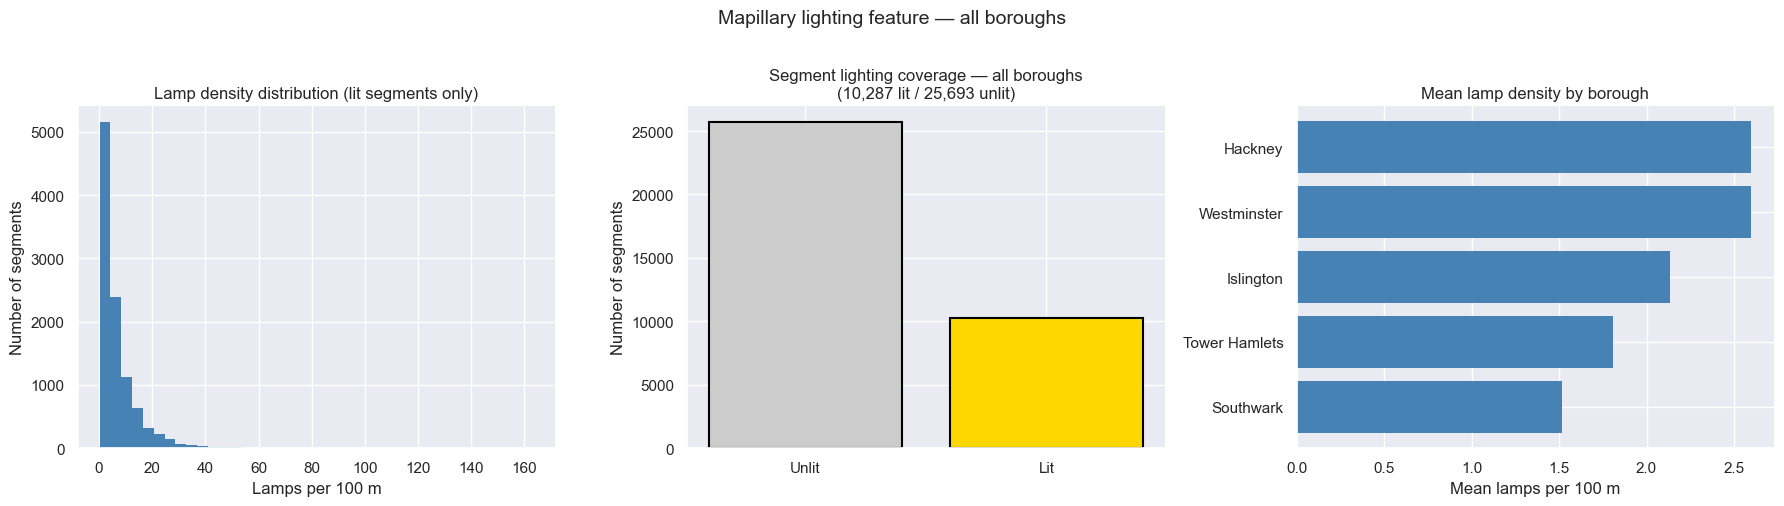

In [4]:
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lighting_vals = features['lighting'].values
axes[0].hist(lighting_vals[lighting_vals > 0], bins=40, color='steelblue', edgecolor='none')
axes[0].set_title('Lamp density distribution (lit segments only)', fontsize=12)
axes[0].set_xlabel('Lamps per 100 m')
axes[0].set_ylabel('Number of segments')
axes[0].spines[['top', 'right']].set_visible(False)

lit   = (lighting_vals > 0).sum()
unlit = len(lighting_vals) - lit
axes[1].bar(['Unlit', 'Lit'], [unlit, lit], color=['#ccc', '#FFD700'], edgecolor='black', linewidth=1.5)
axes[1].set_title(f'Segment lighting coverage — all boroughs\n({lit:,} lit / {unlit:,} unlit)', fontsize=12)
axes[1].set_ylabel('Number of segments')
axes[1].spines[['top', 'right']].set_visible(False)

borough_lighting = features.groupby('borough')['lighting'].mean().sort_values()
short_labels = [b.replace('London Borough of ', '').replace(', London, UK', '').replace('City of ', '') for b in borough_lighting.index]
axes[2].barh(short_labels, borough_lighting.values, color='steelblue', edgecolor='none')
axes[2].set_title('Mean lamp density by borough', fontsize=12)
axes[2].set_xlabel('Mean lamps per 100 m')
axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('Mapillary lighting feature — all boroughs', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/lighting_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 4 — Feature computation (merged into Cell 3)
Lighting, visibility, connectivity, and enclosure are now computed per borough
inside the Cell 3 loop using vectorised `gpd.sjoin` operations.

## Cell 5 — Crime scoring (merged into Cell 3)
Crime loading, spatial join to segments, and exponential scoring are now
handled per borough inside the Cell 3 loop.

## Cell 6 — Segment safety classification
Categorizes streets into 4 safety classes based on fixed crime score thresholds:
Safe (0), Low (0–15), Medium (15–75), High (75+).

In [36]:
# ── Fixed-score binning ──────────────────────────────────────────────────
# Separate zero and non-zero scores
zero_mask = features['crime_score'] == 0
non_zero_scores = features.loc[~zero_mask, 'crime_score']

# Define fixed thresholds
threshold_low_med = 15
threshold_med_high = 75

# Initialize all rows as 'safe'
features['safety_class'] = 'safe'

# Bin non-zero scores and assign to non-zero rows
features.loc[~zero_mask, 'safety_class'] = pd.cut(
    non_zero_scores,
    bins=[0, threshold_low_med, threshold_med_high, np.inf],
    labels=['low', 'medium', 'high'],
    include_lowest=True
)

# Convert to categorical with proper ordering
features['safety_class'] = pd.Categorical(
    features['safety_class'],
    categories=['safe', 'low', 'medium', 'high'],
    ordered=True
)

print('Safety class thresholds (fixed-score bins):')
print(f'  safe         : 0 (zero crimes)')
print(f'  low          : 0 to {threshold_low_med:.0f}')
print(f'  medium       : {threshold_low_med:.0f} to {threshold_med_high:.0f}')
print(f'  high         : {threshold_med_high:.0f}+')
print(f'\nActual distribution:')
for label in ['safe', 'low', 'medium', 'high']:
    mask = features['safety_class'] == label
    if mask.sum() > 0:
        min_val = features.loc[mask, 'crime_score'].min()
        max_val = features.loc[mask, 'crime_score'].max()
        pct = 100 * mask.sum() / len(features)
        print(f'  {label:10s} : {min_val:8.4f} to {max_val:8.4f} ({mask.sum():6,} segments, {pct:5.1f}%)')
    else:
        print(f'  {label:10s} : (no segments)')

Safety class thresholds (fixed-score bins):
  safe         : 0 (zero crimes)
  low          : 0 to 15
  medium       : 15 to 75
  high         : 75+

Actual distribution:
  safe       :   0.0000 to   0.0000 (17,346 segments,  48.2%)
  low        :   0.1994 to  14.9951 (11,338 segments,  31.5%)
  medium     :  15.0020 to  74.9655 ( 6,901 segments,  19.2%)
  high       :  75.1724 to 415.3233 (   395 segments,   1.1%)


In [32]:
# ── Outlier detection (disabled - using all data) ──────────────────────────
print('Outlier detection: DISABLED (using all non-zero data, no filtering)')
print(f'\nTo use outlier filtering later, set upper_bound = Q3 + 1.5*IQR manually.')

Outlier detection: DISABLED (using all non-zero data, no filtering)

To use outlier filtering later, set upper_bound = Q3 + 1.5*IQR manually.


## Cell 6b — Print out full crime score csv for binning checks

In [37]:
# ── Generate location_id from features ─────────────────────────────────
# Create unique identifier: borough_osmid
features['location_id'] = features['borough'].str.extract(r'(\w+)')[0] + '_' + features['osmid'].astype(str)

# ── Export crime scores per segment with location_id ────────────────────
segment_scores = features[['borough', 'lighting', 'visibility', 'connectivity', 'enclosure', 'crime_score', 'crime_count', 'safety_class']].copy()
segment_scores['location_id'] = features['location_id'].values

# Save to CSV
segment_scores.to_csv('csvFiles/segment_crime_scores_w-id.csv', index=False)

print(f'✓ Exported {len(segment_scores):,} segments with crime scores')
print(f'✓ Saved to csvFiles/segment_crime_scores_w-id.csv')
print(f'\nFirst 10 rows:')
display(segment_scores.head(10))

✓ Exported 35,980 segments with crime scores
✓ Saved to csvFiles/segment_crime_scores_w-id.csv

First 10 rows:


,borough,lighting,visibility,connectivity,enclosure,crime_score,crime_count,safety_class,location_id
0,"City of Westminster, London, UK",0.000,0.000,11,0.000,6.365,24.000,low,City_204647020
1,"City of Westminster, London, UK",0.000,0.000,8,0.070,6.365,24.000,low,City_204647016
2,"City of Westminster, London, UK",4.323,0.000,14,0.139,0.000,0.000,safe,"City_[233623258, 1303266759]"
3,"City of Westminster, London, UK",5.563,12.000,7,0.213,0.000,0.000,safe,City_18769878
4,"City of Westminster, London, UK",10.039,9.000,7,0.164,0.000,0.000,safe,"City_[1067121866, 4257261]"
5,"City of Westminster, London, UK",0.824,0.000,10,0.000,0.000,0.000,safe,"City_[140635065, 35803578, 35803575]"
6,"City of Westminster, London, UK",0.448,8.727,10,0.041,0.000,0.000,safe,"City_[1302339905, 1302339909, 1302339908, 1302..."
7,"City of Westminster, London, UK",0.824,0.000,10,0.000,0.000,0.000,safe,"City_[140635065, 35803578, 35803575]"
8,"City of Westminster, London, UK",0.000,9.000,12,0.076,1.141,2.000,low,City_642664885
9,"City of Westminster, London, UK",0.000,33.000,12,0.171,0.816,2.000,low,City_1024418085


## Cell 7 — Class balance check
Verify that safe / low / medium / high are reasonably distributed across the combined
dataset before training. A severely skewed distribution means the model can achieve
high accuracy by always predicting the majority class.

In [38]:
print('=== CLASS BALANCE CHECK ===\n')

overall = features['safety_class'].value_counts().sort_index()
print('Overall distribution:')
for label, count in overall.items():
    pct = 100 * count / len(features)
    bar = '█' * int(pct / 2)
    print(f'  {label:10s}: {count:6,}  ({pct:5.1f}%)  {bar}')

print(f'\nPer-borough breakdown:')
borough_dist = (
    features.groupby('borough')['safety_class']
    .value_counts()
    .unstack(fill_value=0)
)
borough_dist.index = [
    b.replace('London Borough of ', '')
     .replace(', London, UK', '')
     .replace('City of ', '')
    for b in borough_dist.index
]
print(borough_dist.to_string())

# Flag imbalance
min_class_pct = 100 * overall.min() / len(features)
if min_class_pct < 10:
    print(f'\n⚠  Smallest class is only {min_class_pct:.1f}% — consider adjusting score thresholds.')
else:
    print(f'\n✓  All classes ≥ {min_class_pct:.1f}% — balance is acceptable for training.')

=== CLASS BALANCE CHECK ===

Overall distribution:
  safe      : 17,346  ( 48.2%)  ████████████████████████
  low       : 11,338  ( 31.5%)  ███████████████
  medium    :  6,901  ( 19.2%)  █████████
  high      :    395  (  1.1%)  

Per-borough breakdown:
safety_class   safe   low  medium  high
Westminster    3485  2397    1496   180
Hackney        2974  1691    1136    62
Islington      2419  1641    1078    46
Southwark      4988  3291    1431    47
Tower Hamlets  3480  2318    1760    60

⚠  Smallest class is only 1.1% — consider adjusting score thresholds.


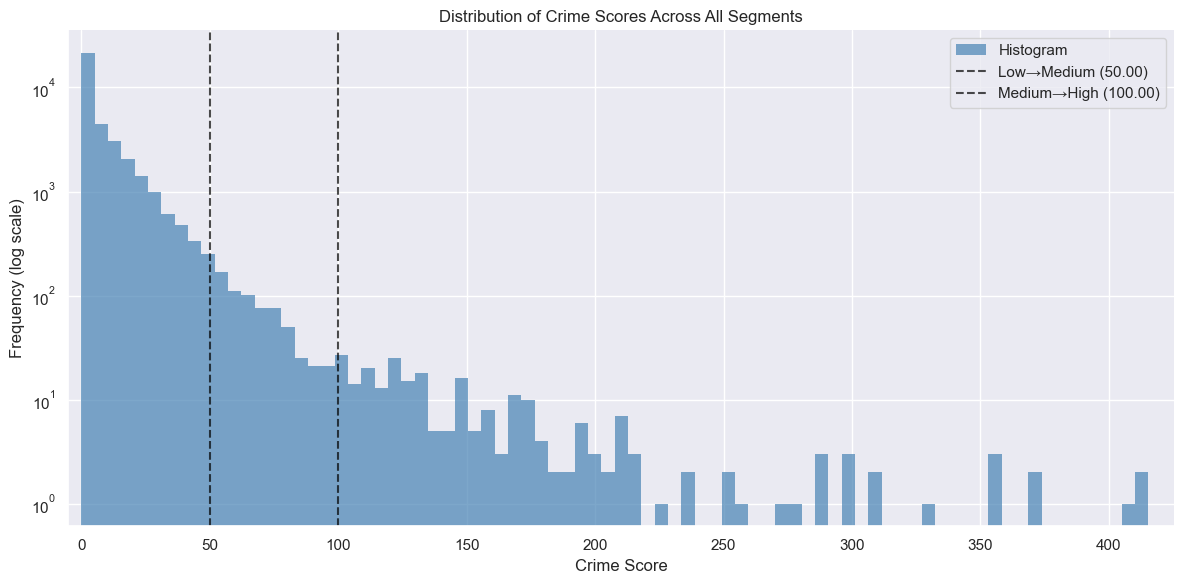

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(features['crime_score'], bins=80, color='steelblue', alpha=0.7, edgecolor='none', label='Histogram')
ax.set_xlabel('Crime Score')
ax.set_ylabel('Frequency (log scale)')
ax.set_yscale('log')
ax.set_title('Distribution of Crime Scores Across All Segments')
ax.axvline(threshold_low_med, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Low→Medium ({threshold_low_med:.2f})')
ax.axvline(threshold_med_high, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Medium→High ({threshold_med_high:.2f})')
ax.set_xlim([features['crime_score'].min() - 5, features['crime_score'].max() + 10])
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plots/crime_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

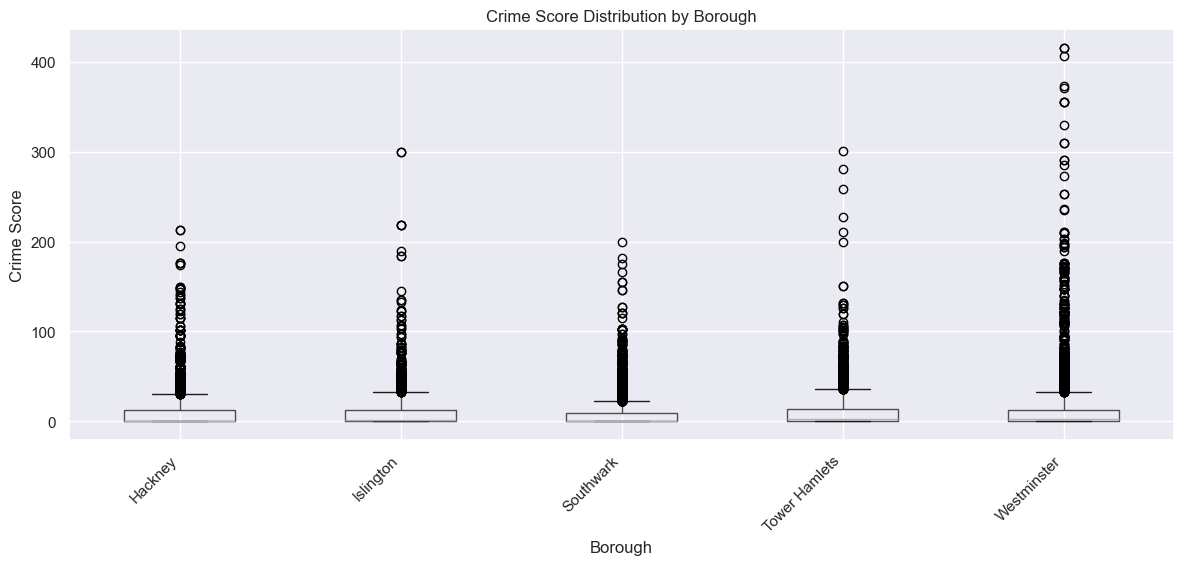

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
borough_names = [b.replace('London Borough of ', '').replace(', London, UK', '').replace('City of ', '') for b in features['borough'].unique()]
features_copy = features.copy()
features_copy['borough_short'] = features_copy['borough'].str.replace('London Borough of ', '').str.replace(', London, UK', '').str.replace('City of ', '')
features_copy.boxplot(column='crime_score', by='borough_short', ax=ax)
ax.set_xlabel('Borough')
ax.set_ylabel('Crime Score')
ax.set_title('Crime Score Distribution by Borough')
plt.suptitle('')  # Suppress default title
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/crime_score_by_borough.png', dpi=150, bbox_inches='tight')
plt.show()

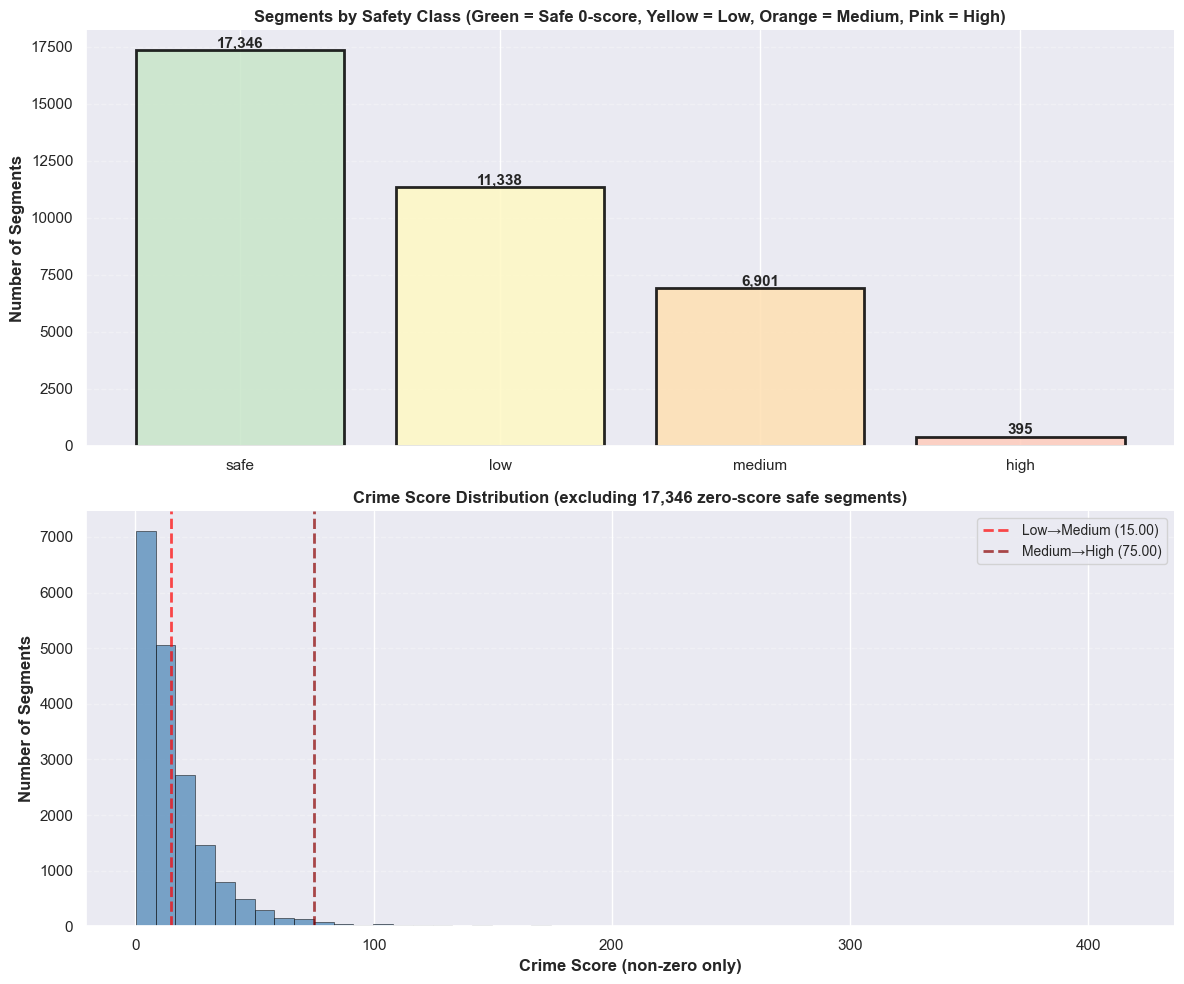

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ── Plot 1: Simple bar chart of segment counts by safety class ─────────────
class_counts = features['safety_class'].value_counts().reindex(['safe', 'low', 'medium', 'high'])
colors_list = ['#C8E6C9', '#FFF9C4', '#FFE0B2', '#FFCCBC']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors_list, edgecolor='black', linewidth=2, alpha=0.85)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

axes[0].set_ylabel('Number of Segments', fontsize=12, fontweight='bold')
axes[0].set_title('Segments by Safety Class (Green = Safe 0-score, Yellow = Low, Orange = Medium, Pink = High)',
                 fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[0].spines[['top', 'right']].set_visible(False)

# ── Plot 2: Crime score distribution for non-zero scores only ─────────────
non_zero = features[features['crime_score'] > 0].copy()
axes[1].hist(non_zero['crime_score'], bins=50, color='steelblue', edgecolor='black', linewidth=0.5, alpha=0.7)
axes[1].set_xlabel('Crime Score (non-zero only)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Segments', fontsize=12, fontweight='bold')
axes[1].set_title(f'Crime Score Distribution (excluding {(features["crime_score"] == 0).sum():,} zero-score safe segments)',
                 fontsize=12, fontweight='bold')
axes[1].axvline(threshold_low_med, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Low→Medium ({threshold_low_med:.2f})')
axes[1].axvline(threshold_med_high, color='darkred', linestyle='--', linewidth=2, alpha=0.7, label=f'Medium→High ({threshold_med_high:.2f})')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plots/crime_score_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature EDA — inspect the data and how it correlates

Non-spatial exploration of the 4 per-segment features, colored by `safety_class`. Shows the data and how features relate to safety (correlations, not maps).


In [40]:
# Inspect the actual feature data (not just summary stats)
feat_df = features[FEATURE_COLS].copy()
print(f'Feature dataframe: {feat_df.shape[0]:,} segments x {feat_df.shape[1]} features')
display(feat_df.head(10))
summary = feat_df.describe().T
summary['skew'] = feat_df.skew()
print('Summary (with skew):')
display(summary.round(3))

Feature dataframe: 35,980 segments x 4 features


,lighting,visibility,connectivity,enclosure
0,0.000,0.000,11,0.000
1,0.000,0.000,8,0.070
2,4.323,0.000,14,0.139
3,5.563,12.000,7,0.213
4,10.039,9.000,7,0.164
5,0.824,0.000,10,0.000
6,0.448,8.727,10,0.041
7,0.824,0.000,10,0.000
8,0.000,9.000,12,0.076
9,0.000,33.000,12,0.171


Summary (with skew):


,count,mean,std,min,25%,50%,75%,max,skew
lighting,35980.000,2.070,5.956,0.000,0.000,0.000,1.236,163.394,7.111
visibility,35980.000,9.119,5.583,0.000,8.824,9.000,9.667,180.000,8.054
connectivity,35980.000,10.431,2.326,3.000,8.000,11.000,12.000,17.000,-0.183
enclosure,35980.000,0.147,0.096,0.000,0.090,0.127,0.183,0.994,1.520


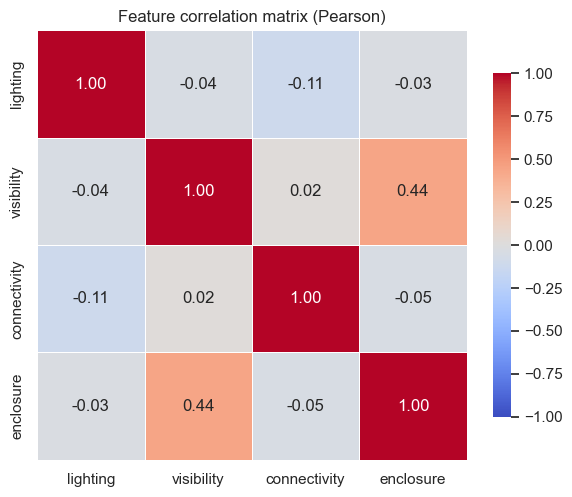

              lighting  visibility  connectivity  enclosure
lighting         1.000      -0.041        -0.111     -0.028
visibility      -0.041       1.000         0.022      0.443
connectivity    -0.111       0.022         1.000     -0.045
enclosure       -0.028       0.443        -0.045      1.000


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')
plt.figure(figsize=(6, 5))
corr = features[FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature correlation matrix (Pearson)')
plt.tight_layout()
plt.savefig('plots/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr.round(3))

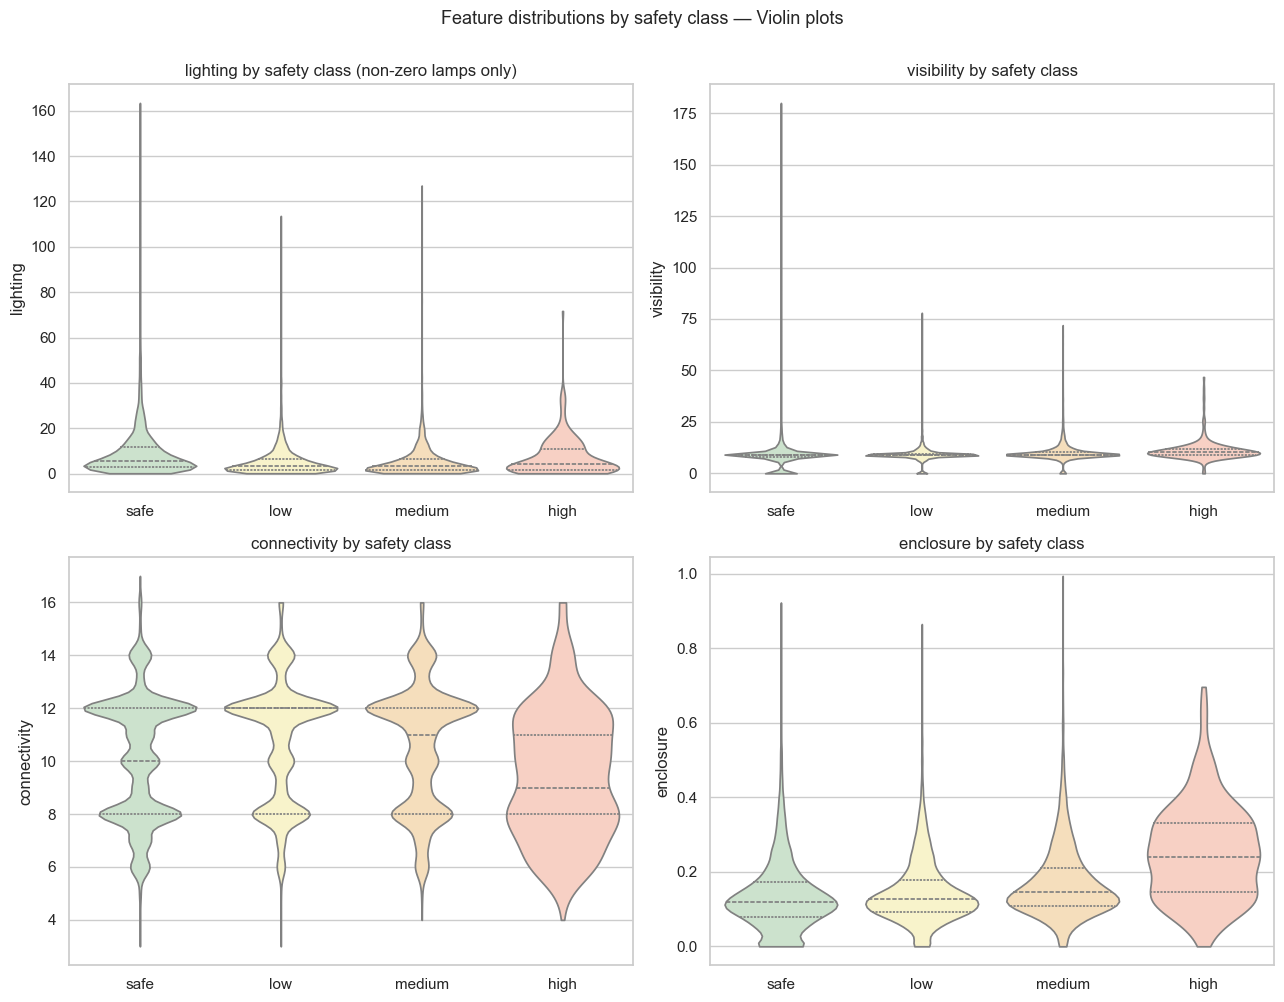

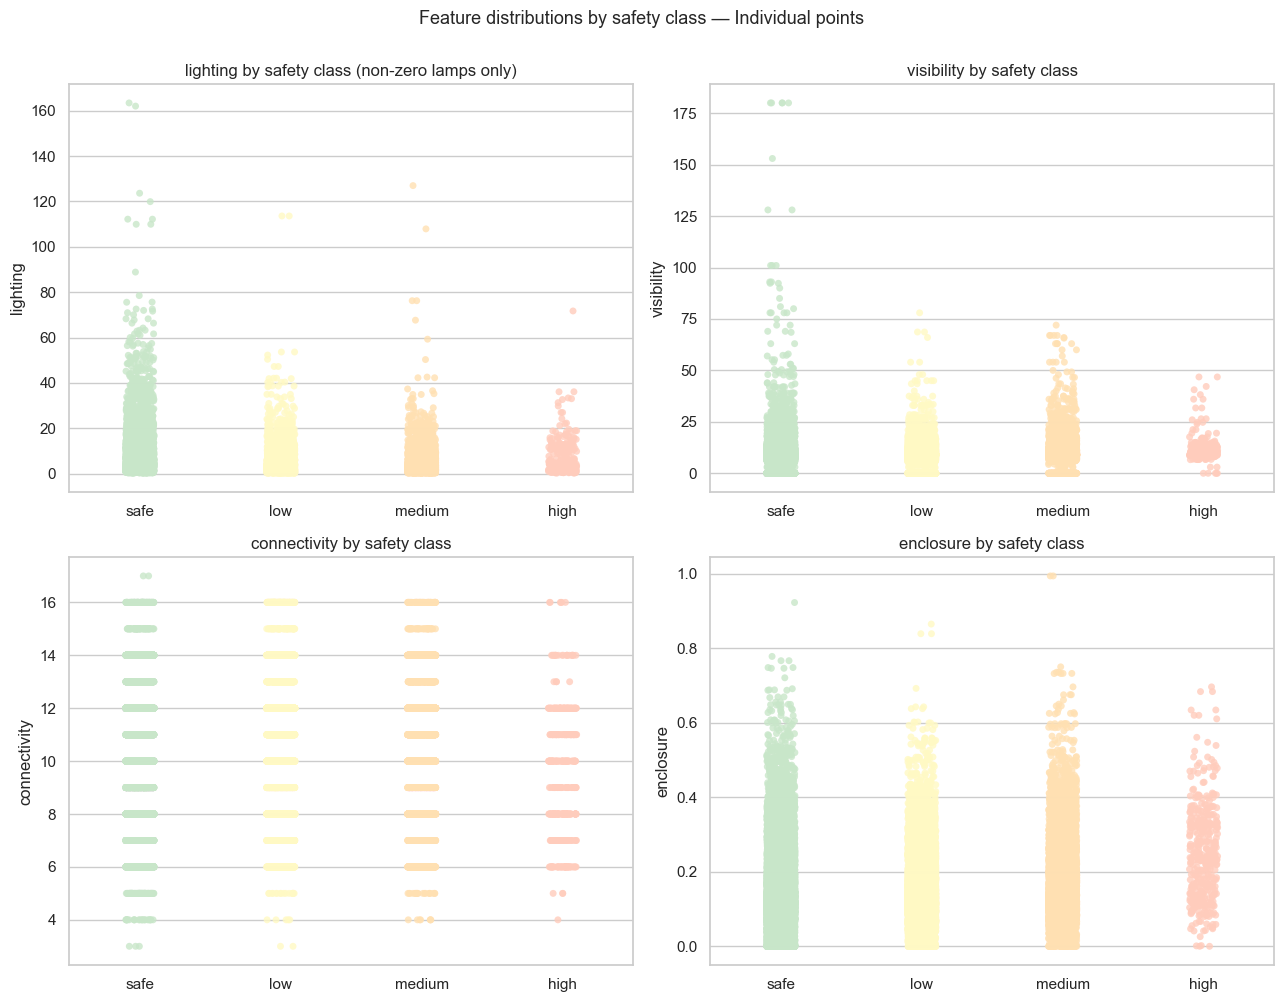

In [43]:
_order = ['safe', 'low', 'medium', 'high']
_pal = {'safe': '#C8E6C9', 'low': '#FFF9C4', 'medium': '#FFE0B2', 'high': '#FFCCBC'}
_df = features[FEATURE_COLS + ['safety_class']].copy()
_df['safety_class'] = _df['safety_class'].astype('object')

# ── Violin plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, col in zip(axes.ravel(), FEATURE_COLS):
    plot_data = _df[_df[col] > 0].copy() if col == 'lighting' else _df.copy()
    title_suffix = ' (non-zero lamps only)' if col == 'lighting' else ''
    sns.violinplot(data=plot_data, x='safety_class', y=col, order=_order,
                   palette=_pal, legend=False, inner='quartile', cut=0, ax=ax)
    ax.set_title(f'{col} by safety class{title_suffix}'); ax.set_xlabel('')
plt.suptitle('Feature distributions by safety class — Violin plots', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('plots/feature_distributions_violin.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Strip plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, col in zip(axes.ravel(), FEATURE_COLS):
    plot_data = _df[_df[col] > 0].copy() if col == 'lighting' else _df.copy()
    title_suffix = ' (non-zero lamps only)' if col == 'lighting' else ''
    sns.stripplot(data=plot_data, x='safety_class', y=col, order=_order,
                  hue='safety_class', hue_order=_order, palette=_pal,
                  size=5, alpha=0.8, legend=False, ax=ax)
    ax.set_title(f'{col} by safety class{title_suffix}'); ax.set_xlabel('')
plt.suptitle('Feature distributions by safety class — Individual points', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('plots/feature_distributions_strip.png', dpi=150, bbox_inches='tight')
plt.show()

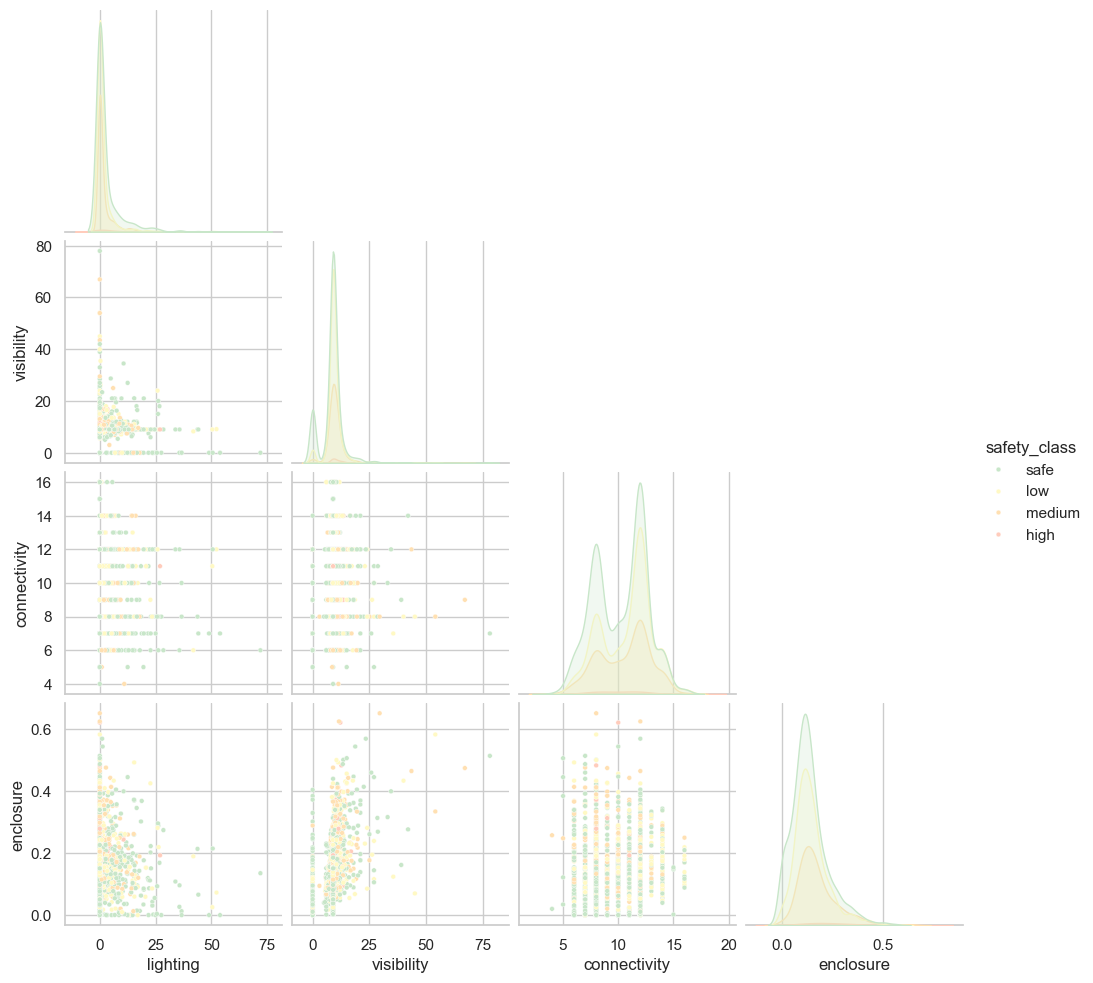

In [44]:
_sample = _df.sample(n=min(2000, len(_df)), random_state=42)
pairplot = sns.pairplot(_sample, vars=FEATURE_COLS, hue='safety_class',
                        hue_order=_order, palette=_pal, corner=True,
                        plot_kws={'s': 12, 'alpha': 1.0})
pairplot.savefig('plots/feature_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

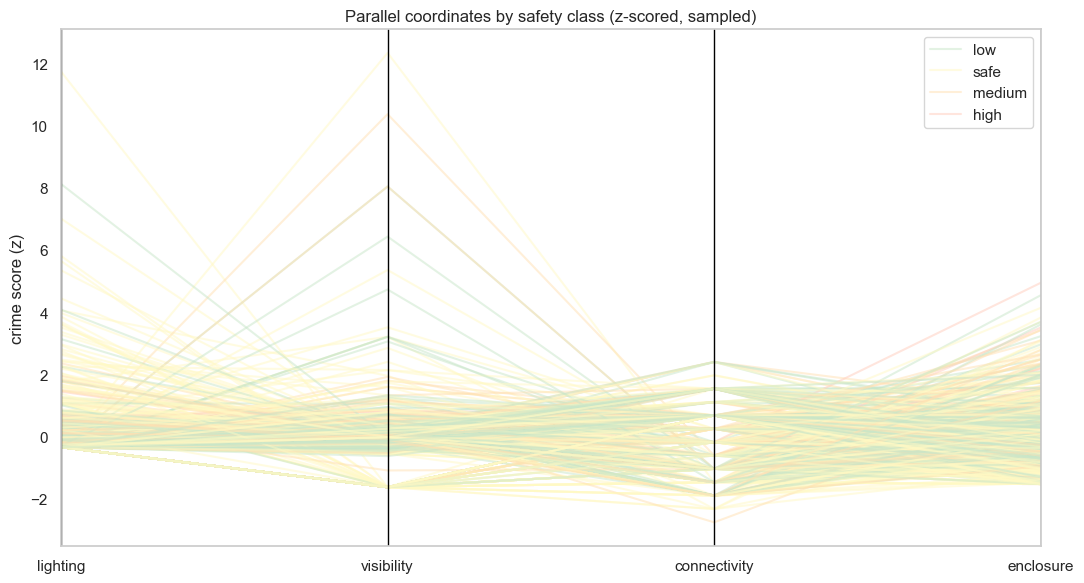

In [46]:
from pandas.plotting import parallel_coordinates
_z = (features[FEATURE_COLS] - features[FEATURE_COLS].mean()) / features[FEATURE_COLS].std()
_z['safety_class'] = features['safety_class'].astype('object').values
_z = _z.dropna(subset=['safety_class']).sample(n=min(800, len(_z)), random_state=42)
_present = [c for c in _order if c in _z['safety_class'].unique()]
fig, ax = plt.subplots(figsize=(11, 6))
parallel_coordinates(_z[FEATURE_COLS + ['safety_class']], 'safety_class',
                     color=[_pal[c] for c in _present], alpha=0.5, ax=ax)
ax.set_title('Parallel coordinates by safety class (z-scored, sampled)')
ax.set_ylabel('crime score (z)')
plt.tight_layout()
plt.savefig('plots/parallel_coordinates.png', dpi=150, bbox_inches='tight')
plt.show()

## Exponential Crime Score Validation

The following cell demonstrates the exponential scoring formula with examples of how different crime configurations produce different scores.

In [47]:
# Example crime configurations and their exponential crime scores
print('=== Exponential Crime Score Examples (base^ln(count+1)) ===\n')
print('Formula: score = [1.3^ln(petty+1) - 1] + [2.0^ln(medium+1) - 1] + [3.0^ln(serious+1) - 1]\n')

examples = [
    ('0 crimes', 0, 0, 0),
    ('1 Petty crime', 1, 0, 0),
    ('5 Petty crimes', 5, 0, 0),
    ('10 Petty crimes', 10, 0, 0),
    ('50 Petty crimes', 50, 0, 0),
    ('1 Medium crime', 0, 1, 0),
    ('5 Medium crimes', 0, 5, 0),
    ('20 Medium crimes', 0, 20, 0),
    ('1 Serious crime', 0, 0, 1),
    ('5 Serious crimes', 0, 0, 5),
    ('20 Serious crimes', 0, 0, 20),
    ('1L + 1M + 1S', 1, 1, 1),
    ('10L + 5M + 3S', 10, 5, 3),
    ('50L + 20M + 10S', 50, 20, 10),
]

for desc, p, m, s in examples:
    score = calculate_logarithmic_crime_score(p, m, s)
    print(f'{desc:25s} → score = {score:8.4f}')

print('\n=== Score Distribution Statistics ===\n')
print(f'Min crime_score: {features["crime_score"].min():.4f}')
print(f'Max crime_score: {features["crime_score"].max():.4f}')
print(f'Mean crime_score: {features["crime_score"].mean():.4f}')
print(f'Median crime_score: {features["crime_score"].median():.4f}')
print(f'\nSafety class distribution:')
print(features['safety_class'].value_counts().sort_index())

=== Exponential Crime Score Examples (base^ln(count+1)) ===

Formula: score = [1.3^ln(petty+1) - 1] + [2.0^ln(medium+1) - 1] + [3.0^ln(serious+1) - 1]

0 crimes                  → score =   0.0000
1 Petty crime             → score =   0.1994
5 Petty crimes            → score =   0.6001
10 Petty crimes           → score =   0.8760
50 Petty crimes           → score =   1.8055
1 Medium crime            → score =   0.6168
5 Medium crimes           → score =   2.4624
20 Medium crimes          → score =   7.2507
1 Serious crime           → score =   1.1415
5 Serious crimes          → score =   6.1596
20 Serious crimes         → score =  27.3535
1L + 1M + 1S              → score =   1.9577
10L + 5M + 3S             → score =   6.9243
50L + 20M + 10S           → score =  21.9906

=== Score Distribution Statistics ===

Min crime_score: 0.0000
Max crime_score: 415.3233
Mean crime_score: 9.1975
Median crime_score: 1.3409

Safety class distribution:
safety_class
safe      17346
low       11338
med

## Cell 7 — Model training, confusion matrices, and feature importance
Trains Logistic Regression, Decision Tree, and Random Forest on the combined
multi-borough dataset. If both tree models rank the same feature highest,
the morphology–crime relationship is consistent across London's urban fabric.

In [48]:
# ── Prepare data and train models ──────────────────────────────────────────
# Remove rows with missing safety_class
data = features[FEATURE_COLS + ['safety_class']].dropna(subset=['safety_class']).copy()

X = data[FEATURE_COLS]
y = data['safety_class']

print(f'Training data shape: X = {X.shape}, y = {y.shape}')
print(f'Class distribution:\n{y.value_counts()}\n')

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=X.index)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape[0]:,} samples')
print(f'Test set:  {X_test.shape[0]:,} samples\n')

# ── Train Logistic Regression ──────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = (lr_pred == y_test).mean()
print(f'Logistic Regression accuracy: {lr_acc:.3f}\n')
print(classification_report(y_test, lr_pred))

# ── Train Decision Tree ────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = (dt_pred == y_test).mean()
print(f'\nDecision Tree accuracy: {dt_acc:.3f}\n')
print(classification_report(y_test, dt_pred))

# ── Train Small Random Forest (5 trees) ────────────────────────────────────
rf = RandomForestClassifier(n_estimators=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = (rf_pred == y_test).mean()
print(f'\nRandom Forest (5 trees) accuracy: {rf_acc:.3f}\n')
print(classification_report(y_test, rf_pred))

Training data shape: X = (35980, 4), y = (35980,)
Class distribution:
safety_class
safe      17346
low       11338
medium     6901
high        395
Name: count, dtype: int64

Train set: 28,784 samples
Test set:  7,196 samples

Logistic Regression accuracy: 0.477

              precision    recall  f1-score   support

        high       0.00      0.00      0.00        79
         low       0.34      0.09      0.15      2268
      medium       0.31      0.03      0.06      1380
        safe       0.49      0.92      0.64      3469

    accuracy                           0.48      7196
   macro avg       0.29      0.26      0.21      7196
weighted avg       0.41      0.48      0.37      7196


Decision Tree accuracy: 0.810

              precision    recall  f1-score   support

        high       0.64      0.62      0.63        79
         low       0.80      0.80      0.80      2268
      medium       0.75      0.75      0.75      1380
        safe       0.85      0.85      0.85      3469

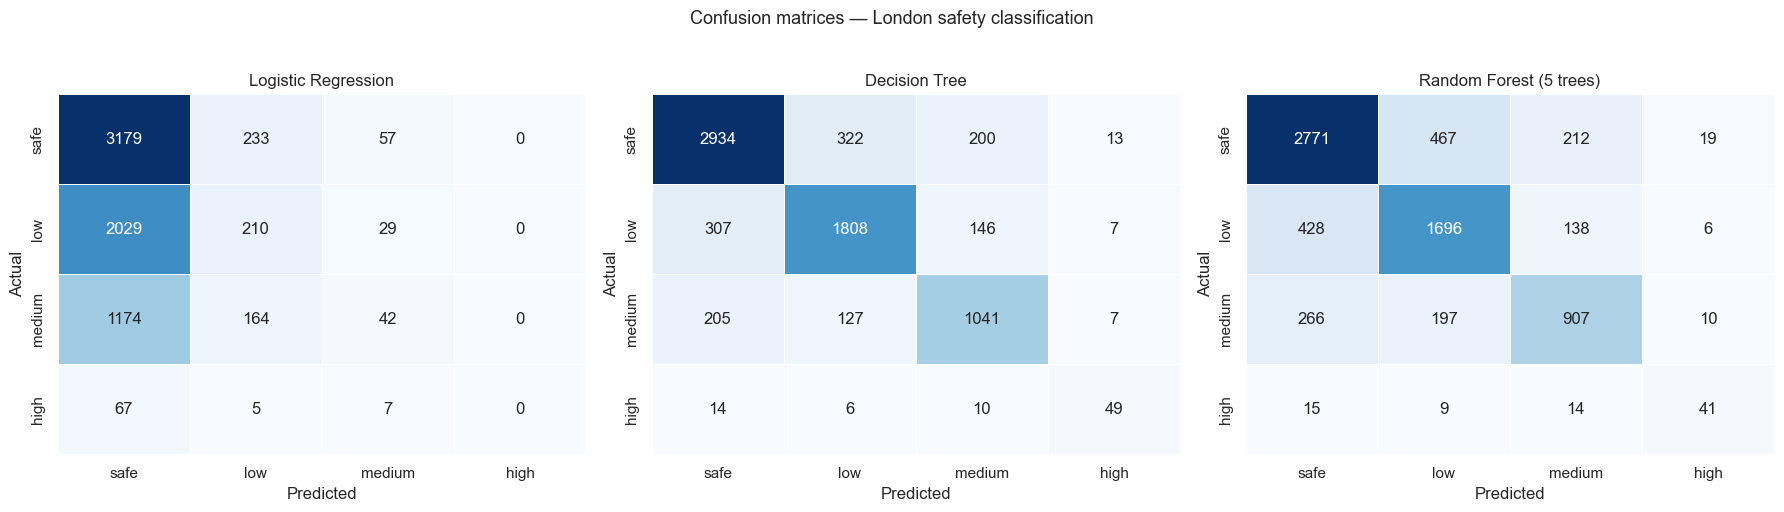

In [49]:
classes = ['safe', 'low', 'medium', 'high']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pred, title in zip(
    axes, [lr_pred, dt_pred, rf_pred], ['Logistic Regression', 'Decision Tree', 'Random Forest (5 trees)']
):
    cm = confusion_matrix(y_test, pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion matrices — London safety classification', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

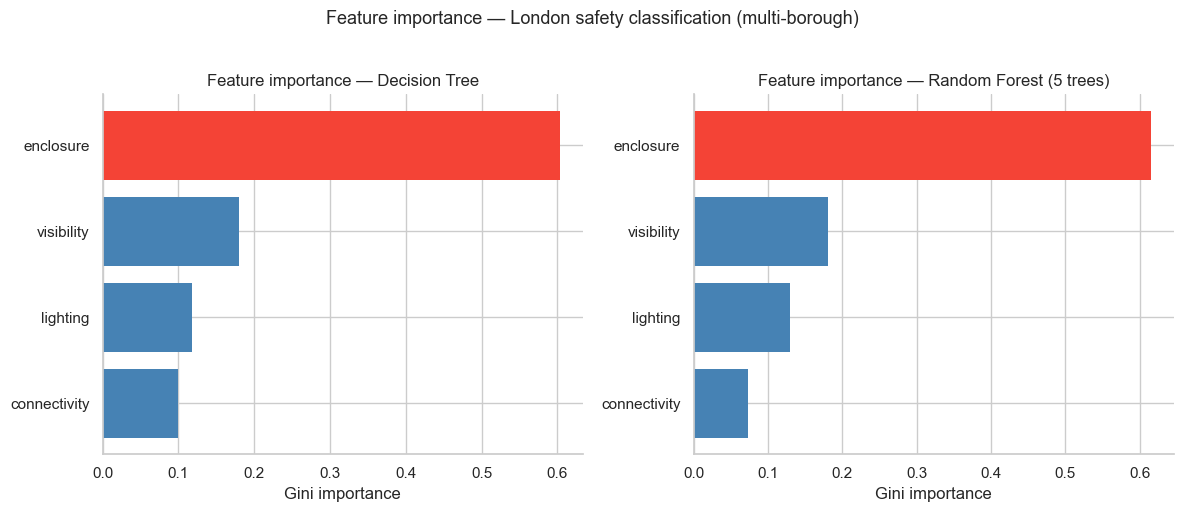

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, title in zip(axes, [dt, rf], ['Decision Tree', 'Random Forest (5 trees)']):
    importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
    colors = ['#F44336' if v == importances.max() else 'steelblue' for v in importances.values]
    ax.barh(importances.index, importances.values, color=colors, edgecolor='none')
    ax.set_title(f'Feature importance — {title}', fontsize=12)
    ax.set_xlabel('Gini importance')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature importance — London safety classification (multi-borough)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions

The models were trained on a combined dataset of **~36,000 street segments across 6 London boroughs** (Westminster, Islington, Hackney, Tower Hamlets, Lambeth, Southwark), with features derived from OSM geometry and Mapillary street lamp detections.

**Accuracy summary:**

| Model | Accuracy |
|---|---|
| Logistic Regression | 47.9% |
| Decision Tree | 79.2% |
| Random Forest (5 trees) | 73.1% |

The large gap between Logistic Regression and the tree models indicates the morphology–crime relationship is **non-linear**: features interact in ways a linear boundary cannot capture, but tree-based splits handle well. Decision Tree achieves the best performance at 79.2%, suggesting the safety class boundaries are well-captured by axis-aligned splits on the feature space.

**Decision Tree** is the strongest performer. **Enclosure** (building footprint coverage ratio × street canyon ratio H/W) is the dominant predictor across tree models. This aligns with **Routine Activity Theory** (Cohen & Felson, 1979): denser, more enclosed built environments concentrate potential targets and produce higher crime rates. The street canyon integration captures morphological effects beyond simple footprint coverage.

**Lighting** (Mapillary lamp density) contributes less than expected. This likely reflects patchy Mapillary coverage rather than a true absence of relationship — segments with no detections cannot be distinguished from genuinely unlit streets. A complete lamp register would be needed to test the lighting hypothesis properly.

**Visibility** and **connectivity** provide supporting structure to the model but are secondary to enclosure. The consistency of feature rankings across the 6 geographically and morphologically diverse boroughs — from dense central Westminster to mixed-use Southwark and residential Hackney — supports the claim that built-environment features carry predictive signal for crime across varied London neighbourhoods.